In [1]:
import time
from collections import deque

import gymnasium as gym
import minigrid
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.distributions import Categorical

from minigrid.wrappers import FlatObsWrapper, ImgObsWrapper

import matplotlib.pyplot as plt

## Run Simulation

This is to observe the simulation before training the model.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [33]:
# Create environment
# env_name = "MiniGrid-Dynamic-Obstacles-16x16-v0"
# env_name = "MiniGrid-SimpleCrossingS11N5-v0"
env_name = "MiniGrid-DoorKey-5x5-v0"
env = gym.make(env_name, render_mode="human")

state, info = env.reset()

total_reward = 0
steps = 250

for step in range(steps):
    # random action
    action = env.action_space.sample()

    next_state, reward, done, truncated, info = env.step(action)

    total_reward += reward

    if step % 50 == 1:
        # print(f"State : {next_state}, Reward {reward} Action: {action}")
        print(f"Step {step} | Reward so far: {total_reward}")

    if done or truncated:
        state, info = env.reset()
    else:
        state = next_state

env.close()

print("Done. Total reward:", total_reward)

Step 1 | Reward so far: 0
Step 51 | Reward so far: 0
Step 101 | Reward so far: 0
Step 151 | Reward so far: 0
Step 201 | Reward so far: 0
Done. Total reward: 0


## Environment processing

In [4]:
class VisitPenaltyWrapper(gym.Wrapper):
    def __init__(self, env, penalty=0.001):
        super().__init__(env)
        self.penalty = penalty
        self._visit_counts = {}

    def reset(self, **kwargs):
        self._visit_counts = {}
        return self.env.reset(**kwargs)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        pos = tuple(self.unwrapped.agent_pos)
        self._visit_counts[pos] = self._visit_counts.get(pos, 0) + 1
        if self._visit_counts[pos] > 1:
            reward -= self.penalty  # flat penalty, no * visit_count scaling
        return obs, reward, terminated, truncated, info

In [5]:
# env_name = "MiniGrid-SimpleCrossingS11N5-v0"
# env_name = "MiniGrid-DoorKey-16x16-v0"
# env_name = "MiniGrid-DoorKey-5x5-v0"
env_name = "MiniGrid-DoorKey-16x16-v0"
env = gym.make(env_name, render_mode=None)
# env = VisitPenaltyWrapper(env, penalty=0.001) 

n_actions = env.action_space.n
img_shape = env.observation_space['image'].shape  # e.g. (11, 11, 3)
H, W, C = img_shape
obs_dim = H * W * C + 1  # flattened image + direction scalar
print(f"Observation dimension {obs_dim}, Actions {n_actions}, Image Shape {img_shape}")

Observation dimension 148, Actions 7, Image Shape (7, 7, 3)


##### Models

In [14]:
env.observation_space['image'].shape

(7, 7, 3)

In [15]:
class LSTMPolicy_CNN(nn.Module):
    """
    Expects the image portion of obs to be (H, W, C) = (7, 7, 3) or (11, 11, 3).
    Direction scalar is appended after CNN embedding.
    """
    def __init__(self, img_shape, act_dim, hidden_size=128):
        super().__init__()
        H, W, C = img_shape  # e.g. (11, 11, 3)

        self.cnn = nn.Sequential(
            nn.Conv2d(C, 16, kernel_size=3, padding=1),  nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Flatten(),
        )
        cnn_out = 32 * H * W

        self.proj = nn.Linear(cnn_out + 1, 128)  # +1 for direction
        self.lstm = nn.LSTM(128, hidden_size, batch_first=True)
        self.actor = nn.Linear(hidden_size, act_dim)
        self.critic = nn.Linear(hidden_size, 1)
        self.hidden_size = hidden_size
        self.img_shape = img_shape

    def forward(self, x, hidden):
        """
        x: [B, T, obs_dim]  where obs_dim = H*W*C + 1
        """
        B, T, D = x.shape
        H, W, C = self.img_shape
        img_dim = H * W * C

        x_flat = x.reshape(B * T, D)
        img = x_flat[:, :img_dim].reshape(B * T, C, H, W)  # channels-first for Conv2d
        direction = x_flat[:, img_dim:]                     # [B*T, 1]

        cnn_feat = self.cnn(img)                            # [B*T, 32*H*W]
        feat = torch.relu(self.proj(torch.cat([cnn_feat, direction], dim=1)))  # [B*T, 128]
        feat = feat.reshape(B, T, -1)

        out, hidden = self.lstm(feat, hidden)
        return self.actor(out), self.critic(out).squeeze(-1), hidden

# ===== MEMORY =====
class Memory:
    def __init__(self):
        self.states = []
        self.actions = []
        self.logprobs = []
        self.rewards = []
        self.dones = []
        self.terminated = []
        self.truncated = []
        self.values = []

    def clear(self):
        self.states.clear()
        self.actions.clear()
        self.logprobs.clear()
        self.rewards.clear()
        self.dones.clear()
        self.terminated.clear()
        self.truncated.clear()
        self.values.clear()

In [16]:
# class LSTMPPO(nn.Module):
#     def __init__(self, obs_dim, act_dim, hidden_size=128):
#         super().__init__()

#         self.fc1 = nn.Linear(obs_dim, 128)
#         self.lstm = nn.LSTM(128, hidden_size, batch_first=True)
#         self.actor = nn.Linear(hidden_size, act_dim)
#         self.critic = nn.Linear(hidden_size, 1)

#         self.hidden_size = hidden_size

#     def forward(self, x, hidden):
#         """
#         x: [B, T, obs_dim]
#         hidden: (h, c), each [1, B, hidden_size]
#         """
#         B, T, D = x.shape

#         x = x.reshape(B * T, D)
#         x = torch.relu(self.fc1(x))
#         x = x.reshape(B, T, -1)

#         out, hidden = self.lstm(x, hidden)          # out: [B, T, H]
#         logits = self.actor(out)                    # [B, T, act_dim]
#         values = self.critic(out).squeeze(-1)       # [B, T]

#         return logits, values, hidden

# # ===== MEMORY =====
# class Memory:
#     def __init__(self):
#         self.states = []
#         self.actions = []
#         self.logprobs = []
#         self.rewards = []
#         self.dones = []

#         self.values = []

#     def clear(self):
#         self.states.clear()
#         self.actions.clear()
#         self.logprobs.clear()
#         self.rewards.clear()
#         self.dones.clear()

#         self.values.clear()

In [17]:
# # ===== MODEL =====
# class ActorCritic(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.shared = nn.Sequential(
#             nn.Linear(obs_dim, 128),
#             nn.ReLU(),
#             nn.Linear(128, 128),
#             nn.ReLU()
#         )
#         self.policy = nn.Linear(128, n_actions)
#         self.value = nn.Linear(128, 1)

#     def forward(self, x):
#         x = self.shared(x)
#         return self.policy(x), self.value(x)

# # ===== MEMORY =====
# class Memory:
#     def __init__(self):
#         self.states = []
#         self.actions = []
#         self.logprobs = []
#         self.rewards = []
#         self.dones = []

#         self.values = []

#     def clear(self):
#         self.states.clear()
#         self.actions.clear()
#         self.logprobs.clear()
#         self.rewards.clear()
#         self.dones.clear()

#         self.values.clear()

## Parameters, and Model Initialization

In [22]:
# model = ActorCritic().to(device)
# model = LSTMPPO(obs_dim, n_actions).to(device)
USE_CNN = True  # ← flip to True to switch policy

if USE_CNN:
    model = LSTMPolicy_CNN(img_shape, n_actions, hidden_size=256).to(device)
else:
    model = LSTMPolicy_MLP(obs_dim, n_actions).to(device)

optimizer = optim.Adam(model.parameters(), lr=3e-4)
memory = Memory()

gamma = 0.99
eps_clip = 0.2
epochs = 4
# update_timestep = 4096
vf_coef = 0.5
max_grad_norm = 0.5
max_episodes = 2000

## Utility Functions

In [18]:
# def get_entropy_coef(ep):
#     recent_success = np.mean(episode_success_history[-100:]) if len(episode_success_history) >= 100 else 0.0
#     if recent_success < 0.05:
#         return 0.05
#     elif recent_success < 0.2:
#         return 0.01
#     elif recent_success < 0.5:
#         return 0.005
#     else:
#         return 0.001

def get_entropy_coef(ep):
    recent_success = np.mean(episode_success_history[-100:]) if len(episode_success_history) >= 100 else 0.0
    # interpolate smoothly between 0.05 and 0.001 as success goes 0 -> 1
    return 0.001 + (0.05 - 0.001) * (1.0 - recent_success) ** 2

def obs_to_flat(obs):
    """Flatten a raw MiniGrid dict obs to a 1-D float32 array: [H*W*C, direction]."""
    img = obs["image"].astype(np.float32).reshape(-1)
    direction = np.array([obs["direction"]], dtype=np.float32)
    return np.concatenate([img, direction])

In [19]:
def select_action(obs, hidden):
    state = obs_to_flat(obs)
    state_t = torch.as_tensor(state, dtype=torch.float32, device=device).view(1, 1, -1)  # [1,1,D]

    with torch.no_grad():
        logits, values, hidden = model(state_t, hidden)
        # logits: [1,1,A], values: [1,1]

        dist = Categorical(logits=logits[:, -1, :])   # [1,A]
        action = dist.sample()                        # [1]
        logprob = dist.log_prob(action)               # [1]
        value = values[:, -1]                         # [1]

    # Store detached single-step tensors
    memory.states.append(torch.as_tensor(state, dtype=torch.float32, device=device))   # [D]
    memory.actions.append(action.squeeze(0).detach())                                   # scalar
    memory.logprobs.append(logprob.squeeze(0).detach())                                 # scalar
    memory.values.append(value.squeeze(0).detach())                                     # scalar

    return action.item(), hidden

# ===== RETURNS =====
def compute_returns(rewards, dones, gamma):
    returns = []
    G = 0.0

    for r, d in zip(reversed(rewards), reversed(dones)):
        if d:
            G = 0.0
        G = r + gamma * G
        returns.insert(0, G)

    return torch.tensor(returns, dtype=torch.float32, device=device)

def init_hidden(batch_size=1):
    h = torch.zeros(1, batch_size, model.hidden_size, device=device)
    c = torch.zeros(1, batch_size, model.hidden_size, device=device)
    return (h, c)

def compute_gae(rewards, terminated, truncated, values, gamma=0.99, lam=0.95):
    advantages = []
    gae = 0.0
    next_value = 0.0

    for r, term, trunc, v in zip(
        reversed(rewards),
        reversed(terminated),
        reversed(truncated),
        reversed(values.tolist()),
    ):
        if term:
            # true terminal: agent reached goal/died, no future value
            next_value = 0.0
            gae = 0.0
        elif trunc:
            # time limit hit: environment cut us off, future value is non-zero
            # next_value carries the critic estimate from the step before (reversed
            # iteration), which is the best bootstrap we have without storing s_{T+1}
            gae = 0.0

        delta = r + gamma * next_value * (1.0 - float(term)) - v
        gae = delta + gamma * lam * gae
        advantages.insert(0, gae)
        next_value = v

    advantages = torch.tensor(advantages, dtype=torch.float32, device=device)
    returns = advantages + values
    return returns, advantages

In [25]:

def update(current_episode):
    if len(memory.states) == 0:
        return None

    states = torch.stack(memory.states, dim=0).to(device)         # [T, D] [8 episodes, 7*7*3+1] size
    actions = torch.stack(memory.actions, dim=0).to(device)       # [T]
    old_logprobs = torch.stack(memory.logprobs, dim=0).to(device) # [T]
    old_values = torch.stack(memory.values, dim=0).to(device)     # [T]

    # returns = compute_returns(memory.rewards, memory.dones, gamma)  # [T]

    returns, advantages = compute_gae(memory.rewards, memory.terminated, memory.truncated, old_values, gamma)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    # advantages = returns - old_values
    # advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    # Build episode segments so hidden state resets at done=True
    segments = []
    start = 0
    for i, d in enumerate(memory.dones):
        if d:
            segments.append((start, i + 1))
            start = i + 1
    if start < len(memory.dones): # last segment is not captured by above loop but it never becomes if d
        segments.append((start, len(memory.dones)))

    epoch_policy_losses = []
    epoch_value_losses = []
    epoch_entropies = []
    epoch_total_losses = []

    for _ in range(epochs):
        logits_chunks = []
        values_chunks = []

        for s, e in segments:
            seq = states[s:e].unsqueeze(0)   # [1, L, D] # L is length of episode
            hidden = init_hidden(batch_size=1)

            logits_seq, values_seq, _ = model(seq, hidden)
            logits_chunks.append(logits_seq.squeeze(0))   # [L, A]
            values_chunks.append(values_seq.squeeze(0))   # [L]

        logits = torch.cat(logits_chunks, dim=0)     # [T, A]
        new_values = torch.cat(values_chunks, dim=0) # [T]

        dist = Categorical(logits=logits)
        logprobs = dist.log_prob(actions)
        entropy = dist.entropy().mean()

        ratios = torch.exp(logprobs - old_logprobs)

        surr1 = ratios * advantages
        surr2 = torch.clamp(ratios, 1 - eps_clip, 1 + eps_clip) * advantages

        policy_loss = -torch.min(surr1, surr2).mean()
        value_loss = F.mse_loss(new_values, returns)

        ent_coef = get_entropy_coef(current_episode)
        loss = policy_loss + vf_coef * value_loss - ent_coef * entropy

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        # --- ADD THIS ---
        with torch.no_grad():
            kl = (old_logprobs - logprobs).mean().item()
        if kl > 0.02:
            break
        # ----------------

        epoch_policy_losses.append(policy_loss.item())
        epoch_value_losses.append(value_loss.item())
        epoch_entropies.append(entropy.item())
        epoch_total_losses.append(loss.item())

    memory.clear()

    return {
        "policy_loss": np.mean(epoch_policy_losses),
        "value_loss": np.mean(epoch_value_losses),
        "entropy": np.mean(epoch_entropies),
        "total_loss": np.mean(epoch_total_losses),
    }


## Training

In [37]:
policy_loss_history = []
value_loss_history = []
entropy_history = []
total_loss_history = []

episode_reward_history = []
episode_success_history = []

update_counter = 0

UPDATE_EVERY_N_EPISODES = 8  # accumulate 16 episodes worth of experience

# In your training loop:
for ep in range(max_episodes):
    obs, _ = env.reset()
    hidden = init_hidden(batch_size=1)
    ep_reward = 0.0
    done = False

    while not done:
        action, hidden = select_action(obs, hidden)
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        memory.rewards.append(reward)
        memory.dones.append(done)
        memory.terminated.append(terminated)
        memory.truncated.append(truncated)
        ep_reward += reward

    episode_reward_history.append(ep_reward)
    episode_success_history.append(1 if ep_reward > 0 else 0)

    # Update every N complete episodes
    if (ep + 1) % UPDATE_EVERY_N_EPISODES == 0:
        stats = update(ep)
        if stats is not None:
            policy_loss_history.append(stats["policy_loss"])
            value_loss_history.append(stats["value_loss"])
            entropy_history.append(stats["entropy"])
            total_loss_history.append(stats["total_loss"])
            update_counter += 1

    if ((ep + 1) % 100) == 0:
        recent_rewards = np.mean(episode_reward_history[-100:])
        recent_success = np.mean(episode_success_history[-100:])
        print(
            f"Episode {ep+1}, Reward: {ep_reward:.3f}, "
            f"AvgReward(100): {recent_rewards:.3f}, SuccessRate(100): {recent_success:.2f}"
        )

# Final leftover update
if len(memory.states) > 0:
    stats = update(ep)
    if stats is not None:
        policy_loss_history.append(stats["policy_loss"])
        value_loss_history.append(stats["value_loss"])
        entropy_history.append(stats["entropy"])
        total_loss_history.append(stats["total_loss"])
        update_counter += 1

env.close()

Episode 100, Reward: 0.981, AvgReward(100): 0.888, SuccessRate(100): 0.92
Episode 200, Reward: 0.969, AvgReward(100): 0.915, SuccessRate(100): 0.96
Episode 300, Reward: 0.985, AvgReward(100): 0.935, SuccessRate(100): 0.99
Episode 400, Reward: 0.926, AvgReward(100): 0.949, SuccessRate(100): 0.99
Episode 500, Reward: 0.976, AvgReward(100): 0.953, SuccessRate(100): 0.99
Episode 600, Reward: 0.984, AvgReward(100): 0.960, SuccessRate(100): 1.00
Episode 700, Reward: 0.981, AvgReward(100): 0.959, SuccessRate(100): 0.99
Episode 800, Reward: 0.971, AvgReward(100): 0.956, SuccessRate(100): 1.00
Episode 900, Reward: 0.966, AvgReward(100): 0.967, SuccessRate(100): 1.00
Episode 1000, Reward: 0.962, AvgReward(100): 0.951, SuccessRate(100): 0.99
Episode 1100, Reward: 0.968, AvgReward(100): 0.957, SuccessRate(100): 0.99
Episode 1200, Reward: 0.973, AvgReward(100): 0.926, SuccessRate(100): 0.96
Episode 1300, Reward: 0.885, AvgReward(100): 0.953, SuccessRate(100): 0.99
Episode 1400, Reward: 0.975, AvgRe

## Plotting

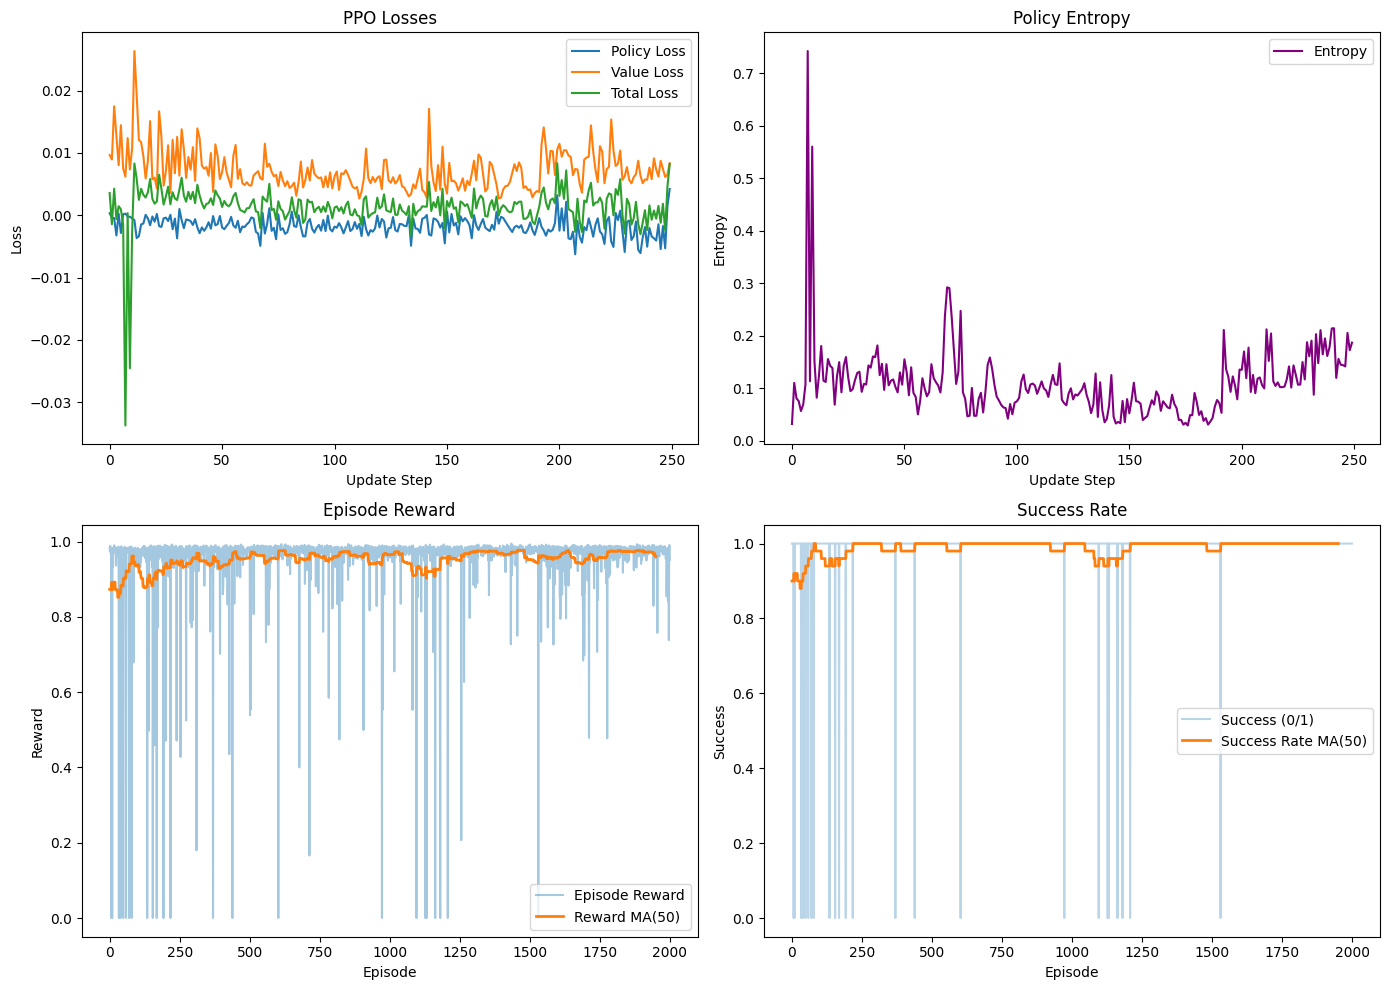

In [38]:
def moving_average(x, window=50):
    if len(x) < window:
        return np.array(x)
    return np.convolve(x, np.ones(window) / window, mode="valid")

plt.figure(figsize=(14, 10))

# --------------------------
# Loss plots
# --------------------------
plt.subplot(2, 2, 1)
plt.plot(policy_loss_history, label="Policy Loss")
plt.plot(value_loss_history, label="Value Loss")
plt.plot(total_loss_history, label="Total Loss")
plt.xlabel("Update Step")
plt.ylabel("Loss")
plt.title("PPO Losses")
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(entropy_history, label="Entropy", color="purple")
plt.xlabel("Update Step")
plt.ylabel("Entropy")
plt.title("Policy Entropy")
plt.legend()

# --------------------------
# Reward plots
# --------------------------
plt.subplot(2, 2, 3)
plt.plot(episode_reward_history, alpha=0.4, label="Episode Reward")
ma_reward = moving_average(episode_reward_history, window=50)
plt.plot(range(len(ma_reward)), ma_reward, label="Reward MA(50)", linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Episode Reward")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(episode_success_history, alpha=0.3, label="Success (0/1)")
ma_success = moving_average(episode_success_history, window=50)
plt.plot(range(len(ma_success)), ma_success, label="Success Rate MA(50)", linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Success")
plt.title("Success Rate")
plt.legend()

plt.tight_layout()
plt.show()

In [39]:
# torch.save(model.state_dict(), "key_solve_ppo_minigrid.pth")

In [46]:
# Create the model instance
# model_name = "ppo_minigrid.pth"
model_name = "key_solve_ppo_minigrid.pth"
USE_CNN = True  # ← flip to True to switch policy

if USE_CNN:
    model = LSTMPolicy_CNN(img_shape, n_actions, hidden_size=256).to(device)
else:
    model = LSTMPolicy_MLP(obs_dim, n_actions).to(device)
state_dict = torch.load(model_name, weights_only=True)
model.load_state_dict(state_dict)

<All keys matched successfully>

## Testing policy

In [47]:
# Create environment
# env_name = "MiniGrid-Dynamic-Obstacles-16x16-v0"
# env_name = "MiniGrid-Empty-16x16-v0"
# env_name = "MiniGrid-Empty-16x16-v0"
eval_envs = [
    "MiniGrid-DoorKey-16x16-v0",
    # "MiniGrid-FourRooms-v0",
    # "MiniGrid-SimpleCrossingS11N5-v0",   # same as training, baseline
    # "MiniGrid-SimpleCrossingS9N1-v0",    # smaller, easier — should be near 100%
    # "MiniGrid-SimpleCrossingS11N5-v0",   # same difficulty
    # "MiniGrid-Empty-16x16-v0",
]

def evaluate(env_name, n_episodes=100, deterministic=True):
    env = gym.make(env_name, render_mode="human")
    successes = 0
    total_rewards = []
    max_steps = 1000
    n_counter = 0

    for ep in range(n_episodes):
        obs, _ = env.reset()
        st = obs_to_flat(obs)
        hidden = init_hidden(batch_size=1)
        ep_reward = 0.0
        done = False

        while not done:
            state_t = torch.as_tensor(st, dtype=torch.float32, device=device).view(1, 1, -1)
            with torch.no_grad():
                logits, values, hidden = model(state_t, hidden)
                if deterministic:
                    action = logits[:, -1, :].argmax(dim=-1).item()
                else:
                    action = Categorical(logits=logits[:, -1, :]).sample().item()

            obs, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward
            truncated = (n_counter == max_steps)
            n_counter += 1
            done = terminated or truncated
            st = obs_to_flat(obs)

        total_rewards.append(ep_reward)
        successes += 1 if ep_reward > 0 else 0

        time.sleep(0.1)

    env.close()
    print(f"Success rate: {successes/n_episodes:.2%}")
    print(f"Avg reward:   {np.mean(total_rewards):.3f}")
    print(f"Min/Max:      {np.min(total_rewards):.3f} / {np.max(total_rewards):.3f}")

for e in eval_envs:
    evaluate(e, n_episodes=10, deterministic=False)

Success rate: 100.00%
Avg reward:   0.971
Min/Max:      0.944 / 0.987


In [59]:
env.close()